# **TASK 1**: Preparing the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Load CSVs
uploaded = files.upload()
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
#train = pd.read_csv('/content/sample_data/train.csv')
#val = pd.read_csv('/content/sample_data/val.csv')

# Quick look table
print("Training set shape:", train.shape)
print("Validation set shape:", val.shape)
print("\nFirst 10 rows of training data:")
train.head(10)

Training set shape: (3164, 11)
Validation set shape: (678, 11)

First 10 rows of training data:


,p1,p2,p3,p4,p5,p6,p7,p8,p9,turn,label_move_cell
0,1,-1,0,1,1,0,-1,0,-1,1,5
1,0,-1,0,-1,-1,1,-1,1,1,-1,2
2,1,0,0,-1,0,-1,-1,0,1,-1,4
3,-1,0,1,-1,1,0,0,0,-1,-1,6
4,1,-1,1,1,-1,-1,0,0,-1,-1,6
5,0,1,-1,-1,-1,0,1,-1,1,-1,5
6,0,-1,1,0,0,0,-1,-1,1,-1,4
7,-1,1,-1,0,0,1,-1,0,0,-1,3
8,0,1,0,1,-1,-1,-1,1,0,1,2
9,-1,0,-1,0,-1,1,1,0,0,-1,1


**Checking the label distribution in the training set:**

Label counts in training set:
label_move_cell
0    765
1    395
2    468
3    253
4    489
5    173
6    273
7    117
8    231
Name: count, dtype: int64


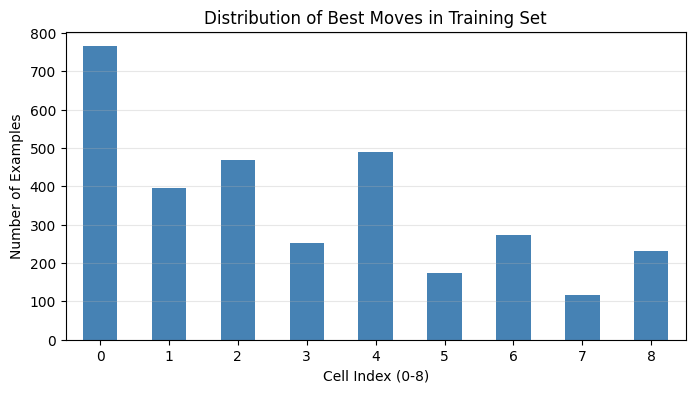

In [ ]:
# Cell 2: Check label distribution
print("Label counts in training set:")
print(train['label_move_cell'].value_counts().sort_index())

# Visualize it
plt.figure(figsize=(8, 4))
train['label_move_cell'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Best Moves in Training Set')
plt.xlabel('Cell Index (0-8)')
plt.ylabel('Number of Examples')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Vistlize 3 random boards from the Dataset :**

In [ ]:

def draw_board(row):

    # Get the 9 cells
    cells = row[['p1','p2','p3','p4','p5','p6','p7','p8','p9']].values
    turn = row['turn']
    label = row['label_move_cell']

    # Convert numbers to symbols based on whose turn it is
    # Current player (1) = X, Opponent (-1) = O
    symbols = []
    for v in cells:
        if v == 1:
            symbols.append('X' if turn == 1 else 'O')
        elif v == -1:
            symbols.append('O' if turn == 1 else 'X')
        else:
            symbols.append('.')

    # Print as 3x3 grid
    print(f"Turn: {'X' if turn == 1 else 'O'} to play")
    print(f"Best move (label): cell {label}")
    print()
    print(f" {symbols[0]} | {symbols[1]} | {symbols[2]} ")
    print("-----------")
    print(f" {symbols[3]} | {symbols[4]} | {symbols[5]} ")
    print("-----------")
    print(f" {symbols[6]} | {symbols[7]} | {symbols[8]} ")
    print()

# Pick 3 random rows and draw them
sample = train.sample(3, random_state=42)
for idx, row in sample.iterrows():
    print(f"--- Row {idx} ---")
    draw_board(row)

--- Row 2618 ---
Turn: O to play
Best move (label): cell 4

 O | . | X 
-----------
 O | . | X 
-----------
 X | X | O 

--- Row 346 ---
Turn: O to play
Best move (label): cell 4

 . | X | . 
-----------
 O | . | . 
-----------
 . | X | . 

--- Row 170 ---
Turn: O to play
Best move (label): cell 1

 X | . | X 
-----------
 O | . | . 
-----------
 . | . | . 



**Split features and labels for train and validation**

In [ ]:
feature_cols = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','turn']
target_col = 'label_move_cell'

X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:  ", X_val.shape)
print("y_val shape:  ", y_val.shape)

print("\nFirst row of X_train:")
print(X_train.iloc[0].values)
print("Corresponding y_train:", y_train.iloc[0])

X_train shape: (3164, 10)
y_train shape: (3164,)
X_val shape:   (678, 10)
y_val shape:   (678,)

First row of X_train:
[ 1 -1  0  1  1  0 -1  0 -1  1]
Corresponding y_train: 5


# **Logistic Regression (Baseline model)**

Without regularization

Logistic Regression (Baseline Model)
Train Accuracy: 0.2506
Validation Accuracy: 0.2198



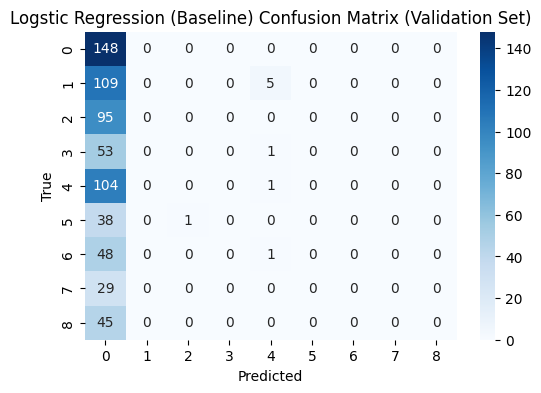

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Train the Logistic Regression Baseline Model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_train_preds = lr_model.predict(X_train)
lr_val_preds = lr_model.predict(X_val)


# Showcase Accuracy
print("Logistic Regression (Baseline Model)")
print(f"Train Accuracy: {accuracy_score(y_train, lr_train_preds):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, lr_val_preds):.4f}\n")

# Visualize with Confusion Matrix
cm = confusion_matrix(y_val, lr_val_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logstic Regression (Baseline) Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Save the Standard Logistic Regression model
import joblib
from google.colab import files

joblib.dump(lr_model, 'standard_logistic_regression.pkl')
print("Standard model saved successfully!")
files.download('standard_logistic_regression.pkl')

With regularization (polynomical features)

Logistic Regression (Polynomial Features)
Train Accuracy: 0.8578
Validation Accuracy: 0.8142


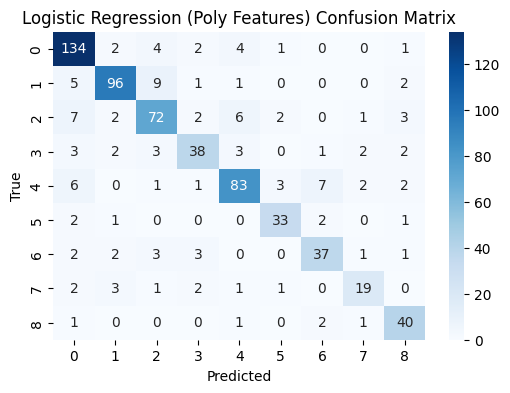

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Added poly features of degree=2 to help the model see pairs of data, to help with underfitting
# Create a pipeline that adds polynomial features first, then runs Logistic Regression to prevent data leakage
poly_lr_model = make_pipeline(PolynomialFeatures(degree=2, interaction_only=True),
                              LogisticRegression(max_iter=3000, random_state=42))

poly_lr_model.fit(X_train, y_train)

poly_train_preds = poly_lr_model.predict(X_train)
poly_val_preds = poly_lr_model.predict(X_val)

print("Logistic Regression (Polynomial Features)")
print(f"Train Accuracy: {accuracy_score(y_train, poly_train_preds):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, poly_val_preds):.4f}")

# Visualize with Confusion Matrix
poly_cm = confusion_matrix(y_val, poly_val_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(poly_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (Poly Features) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Save the Feature Engineered Pipeline model
import joblib
from google.colab import files

joblib.dump(poly_lr_model, 'poly_logistic_regression.pkl')
print("Feature Engineered model saved successfully!")
files.download('poly_logistic_regression.pkl')

# **XGBoost (Advance model)**

**( WITHOUT ) Feature Engineering**






In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss
import time

# Baseline XGBoost (no feature engineering)
xgb_baseline = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=4,
    objective='multi:softmax',
    num_class=9,
    random_state=42,
    eval_metric=['mlogloss', 'merror']   # track both loss and error
)

# Train — pass eval_set so XGBoost records metrics every round
start = time.time()
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
train_time = time.time() - start

# Save the per-round history so we can plot it later
baseline_history = xgb_baseline.evals_result()

# Predictions for accuracy (hard labels)
train_preds = xgb_baseline.predict(X_train)
val_preds   = xgb_baseline.predict(X_val)

# Predictions for log-loss (probabilities)
train_proba = xgb_baseline.predict_proba(X_train)
val_proba   = xgb_baseline.predict_proba(X_val)

train_acc = accuracy_score(y_train, train_preds)
val_acc   = accuracy_score(y_val,   val_preds)
train_loss = log_loss(y_train, train_proba)
val_loss   = log_loss(y_val,   val_proba)

print("Baseline XGBoost (no feature engineering)")
print(f"Training Accuracy:    {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Validation Accuracy:  {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"Accuracy Gap:         {(train_acc - val_acc)*100:.2f} pp")
print()
print(f"Training Log-Loss:    {train_loss:.4f}")
print(f"Validation Log-Loss:  {val_loss:.4f}")
print(f"Loss Gap:             {val_loss - train_loss:.4f}")
print()
print(f"Training time:        {train_time:.2f} seconds")

Baseline XGBoost (no feature engineering)
Training Accuracy:    0.9159  (91.59%)
Validation Accuracy:  0.8333  (83.33%)
Accuracy Gap:         8.26 pp

Training Log-Loss:    0.3376
Validation Log-Loss:  0.5052
Loss Gap:             0.1676

Training time:        1.25 seconds


**Feature Engineering**

In [ ]:
def add_strategic_features(df):
    """Add two-in-a-row features for both players (as suggested in project PDF)."""
    df = df.copy()

    # The 8 winning lines
    lines = [
        [0,1,2], [3,4,5], [6,7,8],   # rows
        [0,3,6], [1,4,7], [2,5,8],   # columns
        [0,4,8], [2,4,6]             # diagonals
    ]

    board = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9']].values

    my_two_in_row = []
    opp_two_in_row = []

    for b in board:
        my_2, opp_2 = 0, 0
        for line in lines:
            vals = [b[i] for i in line]
            my_count = vals.count(1)
            opp_count = vals.count(-1)
            empty = vals.count(0)

            if my_count == 2 and empty == 1:   # I can win next move
                my_2 += 1
            if opp_count == 2 and empty == 1:  # Opponent threatens to win
                opp_2 += 1

        my_two_in_row.append(my_2)
        opp_two_in_row.append(opp_2)

    df['my_two_in_row']  = my_two_in_row
    df['opp_two_in_row'] = opp_two_in_row
    return df

train_fe = add_strategic_features(train)
val_fe   = add_strategic_features(val)

feature_cols_fe = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','turn',
                   'my_two_in_row','opp_two_in_row']

X_train_fe = train_fe[feature_cols_fe]
y_train_fe = train_fe['label_move_cell']
X_val_fe   = val_fe[feature_cols_fe]
y_val_fe   = val_fe['label_move_cell']

print("Feature count:", X_train_fe.shape[1])
print("(10 original + 2 engineered = 12 features)")

Feature count: 12
(10 original + 2 engineered = 12 features)


In [ ]:
def add_rich_features(df):
    """Richer feature engineering for Random Forest."""
    df = df.copy()

    lines = [
        [0,1,2], [3,4,5], [6,7,8],   # rows
        [0,3,6], [1,4,7], [2,5,8],   # columns
        [0,4,8], [2,4,6]             # diagonals
    ]

    board = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9']].values
    n = len(board)

    win_at   = np.zeros((n, 9), dtype=int)   # placing me here wins
    block_at = np.zeros((n, 9), dtype=int)   # placing me here blocks opp

    my_two  = np.zeros(n, dtype=int)
    opp_two = np.zeros(n, dtype=int)
    my_one  = np.zeros(n, dtype=int)
    opp_one = np.zeros(n, dtype=int)

    for i in range(n):
        b = board[i]
        for line in lines:
            vals = [b[c] for c in line]
            mc, oc, ec = vals.count(1), vals.count(-1), vals.count(0)

            if mc == 2 and ec == 1:
                my_two[i] += 1
                for c in line:
                    if b[c] == 0:
                        win_at[i, c] = 1
            if oc == 2 and ec == 1:
                opp_two[i] += 1
                for c in line:
                    if b[c] == 0:
                        block_at[i, c] = 1
            if mc == 1 and ec == 2: my_one[i]  += 1
            if oc == 1 and ec == 2: opp_one[i] += 1

    df['my_two_in_row']  = my_two
    df['opp_two_in_row'] = opp_two
    df['my_one_in_row']  = my_one
    df['opp_one_in_row'] = opp_one

    for c in range(9):
        df[f'win_at_{c}']   = win_at[:, c]
        df[f'block_at_{c}'] = block_at[:, c]

    df['center_mine']  = (board[:, 4] ==  1).astype(int)
    df['center_opp']   = (board[:, 4] == -1).astype(int)

    corners = [0, 2, 6, 8]
    df['corners_mine'] = sum((board[:, c] ==  1).astype(int) for c in corners)
    df['corners_opp']  = sum((board[:, c] == -1).astype(int) for c in corners)

    df['empty_count']  = (board == 0).sum(axis=1)

    return df


train_rf  = add_rich_features(train)
val_rf    = add_rich_features(val)

rf_feature_cols = [c for c in train_rf.columns if c != 'label_move_cell']
X_train_rf  = train_rf[rf_feature_cols]
y_train_rf  = train_rf['label_move_cell']
X_val_rf    = val_rf[rf_feature_cols]
y_val_rf    = val_rf['label_move_cell']

print(f"Rich FE feature count: {X_train_rf.shape[1]}")
print(f"(10 raw + 4 line counts + 18 per-cell + 5 board-level)")

Rich FE feature count: 37
(10 raw + 4 line counts + 18 per-cell + 5 board-level)


**Train XGBoost on engineered features**



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss
import time

# XGBoost with Feature Engineering + L2 Regularization (Final Model)
xgb_fe = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=3,
    reg_lambda=11,
    objective='multi:softmax',
    num_class=9,
    random_state=42,
    eval_metric=['mlogloss', 'merror']
)

start = time.time()
xgb_fe.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_train_fe, y_train_fe), (X_val_fe, y_val_fe)],
    verbose=False)
train_time = time.time() - start

# Save the per round history
final_history = xgb_fe.evals_result()

train_preds = xgb_fe.predict(X_train_fe)
val_preds   = xgb_fe.predict(X_val_fe)
train_proba = xgb_fe.predict_proba(X_train_fe)
val_proba   = xgb_fe.predict_proba(X_val_fe)

train_acc = accuracy_score(y_train_fe, train_preds)
val_acc   = accuracy_score(y_val_fe,   val_preds)
train_loss = log_loss(y_train_fe, train_proba)
val_loss   = log_loss(y_val_fe,   val_proba)


print("Final XGBoost Model (FE + depth=4 + L2 regularization)")
print(f"Training Accuracy:    {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Validation Accuracy:  {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"Accuracy Gap:         {(train_acc - val_acc)*100:.2f} pp")
print()
print(f"Training Log-Loss:    {train_loss:.4f}")
print(f"Validation Log-Loss:  {val_loss:.4f}")
print(f"Loss Gap:             {val_loss - train_loss:.4f}")
print()
print(f"Training time:        {train_time:.2f} seconds")

Final XGBoost Model (FE + depth=4 + L2 regularization)
Training Accuracy:    0.9030  (90.30%)
Validation Accuracy:  0.8628  (86.28%)
Accuracy Gap:         4.01 pp

Training Log-Loss:    0.3958
Validation Log-Loss:  0.4932
Loss Gap:             0.0974

Training time:        1.54 seconds


**Plot**

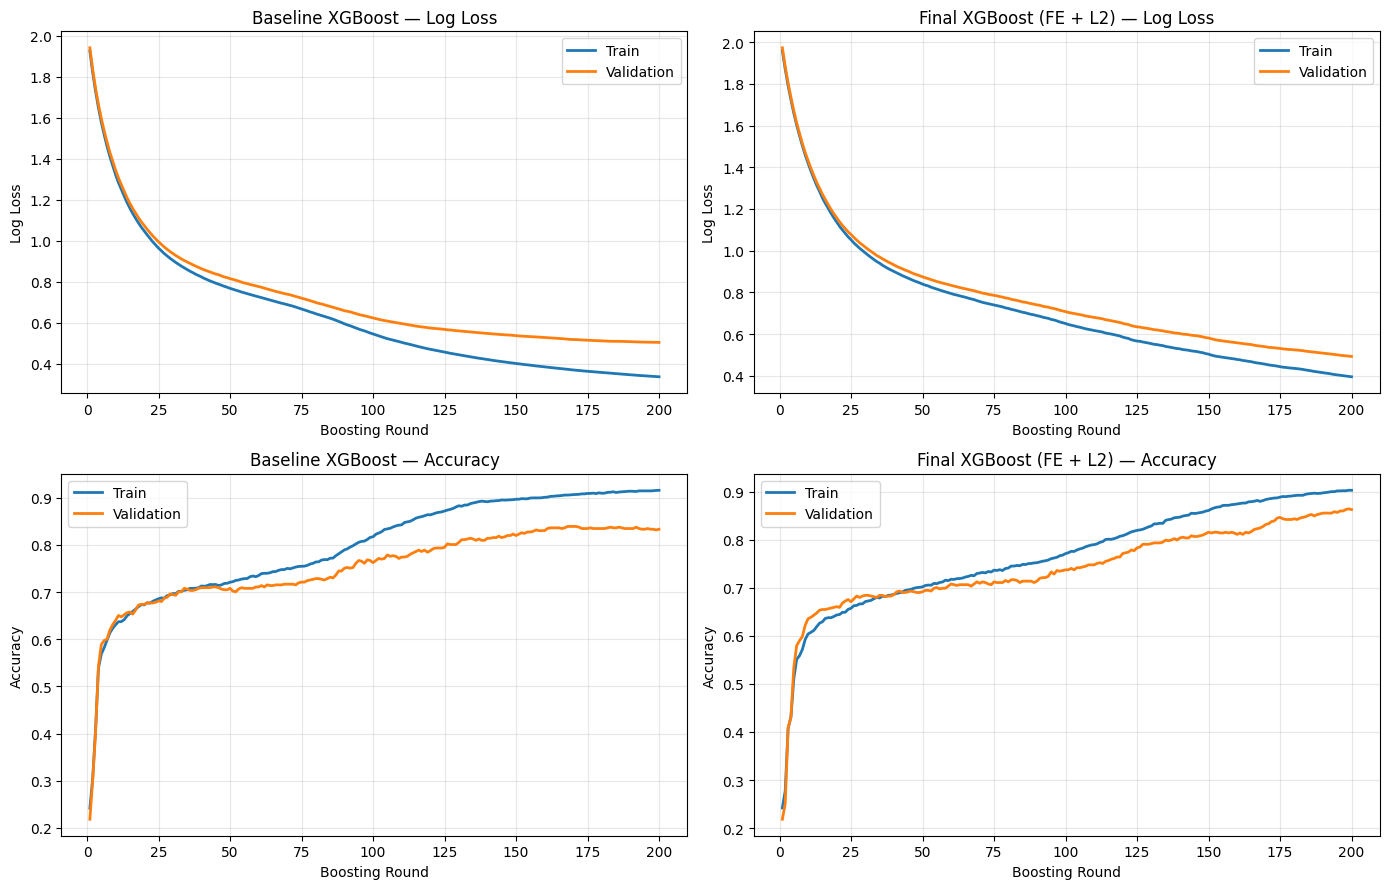

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the per round metrics from both models
# eval_set order was [train, val] validation_0 = train, validation_1 = val
b_train_loss = baseline_history['validation_0']['mlogloss']
b_val_loss   = baseline_history['validation_1']['mlogloss']
b_train_acc  = [1 - e for e in baseline_history['validation_0']['merror']]
b_val_acc    = [1 - e for e in baseline_history['validation_1']['merror']]

f_train_loss = final_history['validation_0']['mlogloss']
f_val_loss   = final_history['validation_1']['mlogloss']
f_train_acc  = [1 - e for e in final_history['validation_0']['merror']]
f_val_acc    = [1 - e for e in final_history['validation_1']['merror']]

rounds_b = np.arange(1, len(b_train_loss) + 1)
rounds_f = np.arange(1, len(f_train_loss) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: Loss for baseline
axes[0, 0].plot(rounds_b, b_train_loss, label='Train', linewidth=2)
axes[0, 0].plot(rounds_b, b_val_loss,   label='Validation', linewidth=2)
axes[0, 0].set_title('Baseline XGBoost — Log Loss')
axes[0, 0].set_xlabel('Boosting Round')
axes[0, 0].set_ylabel('Log Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Top-right: Loss for final
axes[0, 1].plot(rounds_f, f_train_loss, label='Train', linewidth=2)
axes[0, 1].plot(rounds_f, f_val_loss,   label='Validation', linewidth=2)
axes[0, 1].set_title('Final XGBoost (FE + L2) — Log Loss')
axes[0, 1].set_xlabel('Boosting Round')
axes[0, 1].set_ylabel('Log Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bottom-left: Accuracy for baseline
axes[1, 0].plot(rounds_b, b_train_acc, label='Train', linewidth=2)
axes[1, 0].plot(rounds_b, b_val_acc,   label='Validation', linewidth=2)
axes[1, 0].set_title('Baseline XGBoost — Accuracy')
axes[1, 0].set_xlabel('Boosting Round')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Bottom-right: Accuracy for final
axes[1, 1].plot(rounds_f, f_train_acc, label='Train', linewidth=2)
axes[1, 1].plot(rounds_f, f_val_acc,   label='Validation', linewidth=2)
axes[1, 1].set_title('Final XGBoost (FE + L2) — Accuracy')
axes[1, 1].set_xlabel('Boosting Round')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Random Forest (Advance model)**

**( WITHOUT ) Feature Engineering**

In [ ]:
# import needed libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import time

# class-weight setup
classes    = np.arange(9) # nine classes

# calculate a weight for each class so rare classes get higher weights and vice versa
balanced_w = dict(zip(classes,
    compute_class_weight('balanced', classes=classes, y=y_train)))

# set trees train
TOTAL_TREES = 200
CHECKPOINT  = 25 # list of forest sizes
checkpoints = list(range(CHECKPOINT, TOTAL_TREES + 1, CHECKPOINT))

# the classifier definition
rf_baseline = RandomForestClassifier(
    n_estimators=CHECKPOINT, # start training with 25 trees
    max_depth=12, # no tree can grow deeper than 12 splits from root
    min_samples_leaf=3, # every leaf conatins 3 training samples or more
    min_samples_split=10, # a node must have 10 samples or more
    max_features=0.3, # at each split, only consider 30% of features for generalization
    max_samples=0.7, # each tree trains on a random 70% bootstrap
    ccp_alpha=0.001, # cost complexity pruning
    class_weight=balanced_w, # apply the imbalance correction
    warm_start=True, # add new trees to existing forest instead of rebuilding
    random_state=42, # fixed seed for reproducibility
    n_jobs=-1 # use all CPU cores in parallel
)

# to store metrics at each checkpoint
baseline_history = {
    'n_trees':    [],
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

# training loop, starts by 25 tree then increment each time
for n in checkpoints:
    rf_baseline.n_estimators = n
    rf_baseline.fit(X_train, y_train)

    # probability per class
    train_proba = rf_baseline.predict_proba(X_train)
    val_proba   = rf_baseline.predict_proba(X_val)

    # single most likely class
    train_preds = rf_baseline.predict(X_train)
    val_preds   = rf_baseline.predict(X_val)

    # record train and val log loss and accuracy at this forest
    baseline_history['n_trees'].append(n)
    baseline_history['train_loss'].append(log_loss(y_train, train_proba))
    baseline_history['val_loss'].append(log_loss(y_val,   val_proba))
    baseline_history['train_acc'].append(accuracy_score(y_train, train_preds))
    baseline_history['val_acc'].append(accuracy_score(y_val,     val_preds))

# the final tree count (200) metrics
train_acc  = baseline_history['train_acc'][-1]
val_acc    = baseline_history['val_acc'][-1]
train_loss = baseline_history['train_loss'][-1]
val_loss   = baseline_history['val_loss'][-1]

# printing results
print("=" * 55)
print("Random Forest WITHOUT Feature Engineering")
print("=" * 55)
print(f"Training Accuracy:    {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Validation Accuracy:  {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"Accuracy Gap:         {(train_acc - val_acc)*100:.2f} pp")
print(f"\nTraining Log-Loss:    {train_loss:.4f}")
print(f"Validation Log-Loss:  {val_loss:.4f}")
print(f"Loss Gap:             {val_loss - train_loss:.4f}")
print("=" * 55)

Random Forest WITHOUT Feature Engineering
Training Accuracy:    0.8714  (87.14%)
Validation Accuracy:  0.7522  (75.22%)
Accuracy Gap:         11.92 pp

Training Log-Loss:    0.8679
Validation Log-Loss:  1.0376
Loss Gap:             0.1698


**Feature Engineering and training**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
import time

# set trees train
TOTAL_TREES = 200
CHECKPOINT  = 25 # list of forest sizes
checkpoints = list(range(CHECKPOINT, TOTAL_TREES + 1, CHECKPOINT))

# the classifier definition
rf_fe = RandomForestClassifier(
    n_estimators=CHECKPOINT, # start training with 25 trees
    max_depth=12, # no tree can grow deeper than 12 splits from root
    min_samples_leaf=3, # every leaf conatins 3 training samples or more
    min_samples_split=10, # a node must have 10 samples or more
    max_features=0.3, # at each split, only consider 30% of features for generalization
    max_samples=0.7, # each tree trains on a random 70% bootstrap
    ccp_alpha=0.001, # cost complexity pruning
    class_weight=balanced_w, # apply the imbalance correction
    warm_start=True, # add new trees to existing forest instead of rebuilding
    random_state=42, # fixed seed for reproducibility
    n_jobs=-1 # use all CPU cores in parallel
)

# to store metrics at each checkpoint
final_history = {
    'n_trees':    [],
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

# training loop, starts by 25 tree then increment each time
for n in checkpoints:
    rf_fe.n_estimators = n
    rf_fe.fit(X_train_rf, y_train_rf)

    # probability per class
    train_proba = rf_fe.predict_proba(X_train_rf)
    val_proba   = rf_fe.predict_proba(X_val_rf)

    # single most likely class
    train_preds = rf_fe.predict(X_train_rf)
    val_preds   = rf_fe.predict(X_val_rf)

    # record train and val log loss and accuracy at this forest
    final_history['n_trees'].append(n)
    final_history['train_loss'].append(log_loss(y_train_rf, train_proba))
    final_history['val_loss'].append(log_loss(y_val_rf,   val_proba))
    final_history['train_acc'].append(accuracy_score(y_train_rf, train_preds))
    final_history['val_acc'].append(accuracy_score(y_val_rf,     val_preds))

# the final tree count (200) metrics
train_acc  = final_history['train_acc'][-1]
val_acc    = final_history['val_acc'][-1]
train_loss = final_history['train_loss'][-1]
val_loss   = final_history['val_loss'][-1]

# printing results
print("Random Forest WITH Feature Engineering")
print(f"Training Accuracy:    {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Validation Accuracy:  {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"Accuracy Gap:         {(train_acc - val_acc)*100:.2f} pp")
print(f"\nTraining Log-Loss:    {train_loss:.4f}")
print(f"Validation Log-Loss:  {val_loss:.4f}")
print(f"Loss Gap:             {val_loss - train_loss:.4f}")

Random Forest WITH Feature Engineering
Training Accuracy:    0.8271  (82.71%)
Validation Accuracy:  0.7640  (76.40%)
Accuracy Gap:         6.31 pp

Training Log-Loss:    0.7453
Validation Log-Loss:  0.8550
Loss Gap:             0.1097


**Plot**

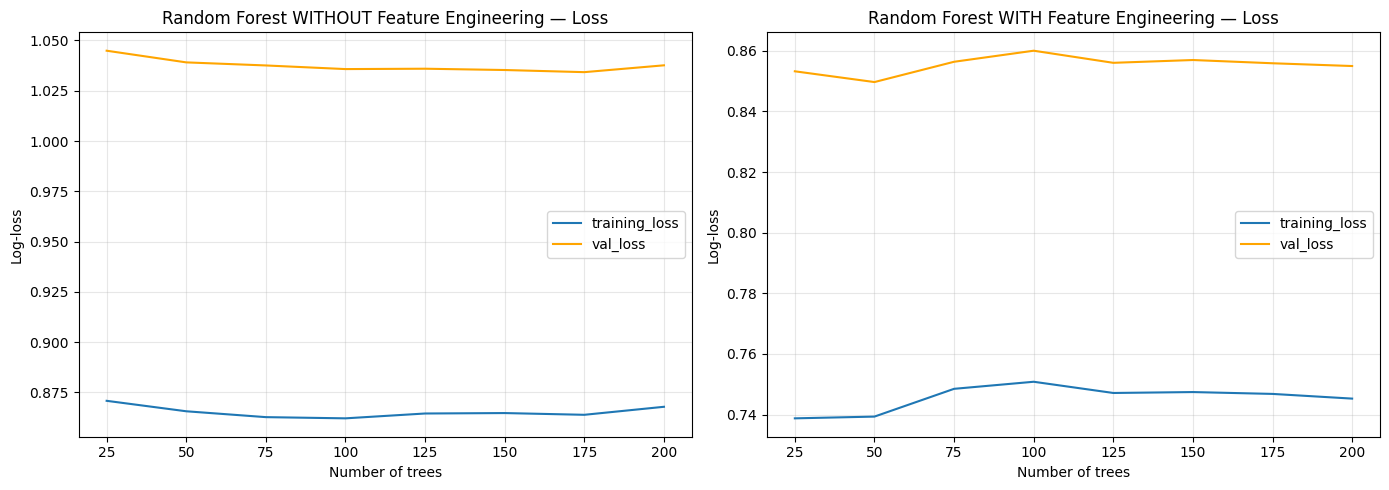

In [ ]:
import matplotlib.pyplot as plt

b = baseline_history
f = final_history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot a figure for training and val losses (without feature engineering)
axes[0].plot(b['n_trees'], b['train_loss'], label='training_loss')
axes[0].plot(b['n_trees'], b['val_loss'],   label='val_loss', color='orange')
axes[0].set_title('Random Forest WITHOUT Feature Engineering — Loss')
axes[0].set_xlabel('Number of trees')
axes[0].set_ylabel('Log-loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# plot a figure for training and val losses (with feature engineering)
axes[1].plot(f['n_trees'], f['train_loss'], label='training_loss')
axes[1].plot(f['n_trees'], f['val_loss'],   label='val_loss', color='orange')
axes[1].set_title('Random Forest WITH Feature Engineering — Loss')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('Log-loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

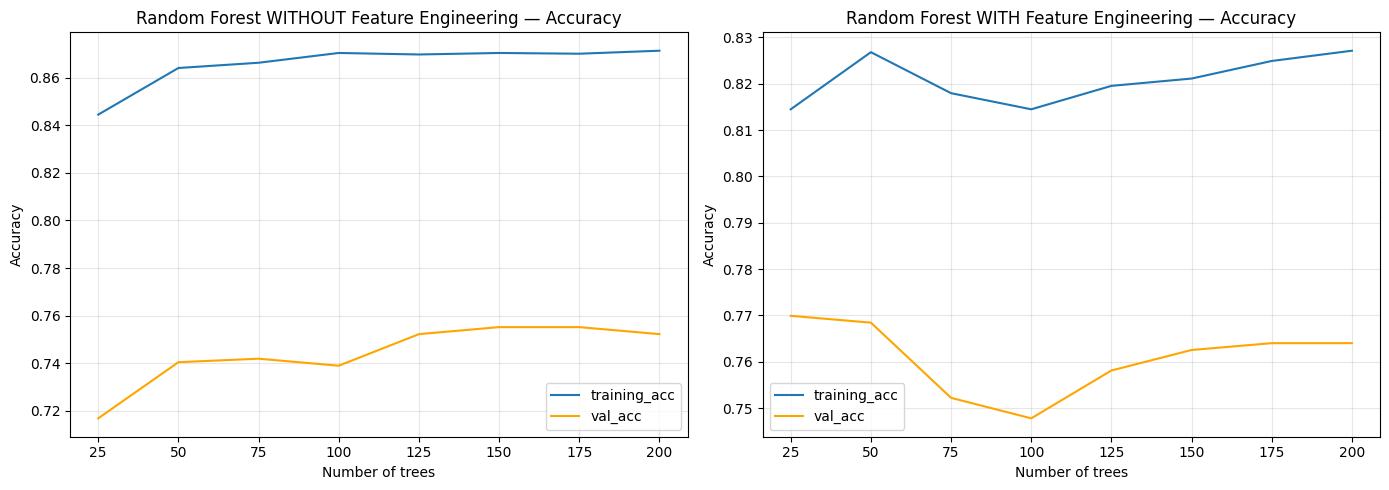

In [ ]:
import matplotlib.pyplot as plt

b = baseline_history
f = final_history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RF without FE
axes[0].plot(b['n_trees'], b['train_acc'], label='training_acc')
axes[0].plot(b['n_trees'], b['val_acc'],   label='val_acc', color='orange')
axes[0].set_title('Random Forest WITHOUT Feature Engineering — Accuracy')
axes[0].set_xlabel('Number of trees')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: RF with FE
axes[1].plot(f['n_trees'], f['train_acc'], label='training_acc')
axes[1].plot(f['n_trees'], f['val_acc'],   label='val_acc', color='orange')
axes[1].set_title('Random Forest WITH Feature Engineering — Accuracy')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Save Random Forest & XGBoost best models (.pkl)**

In [ ]:
import joblib
import numpy as np

# Save Random Forest (with FE)
joblib.dump({
    'model': rf_fe,
    'feature_cols': rf_feature_cols,
    'name': 'Random Forest (FE, tuned)',
}, 'rf_model.pkl')

# Save XGBoost (with FE) — replace `xgb_fe` with your XGBoost variable name if different
joblib.dump({
    'model': xgb_fe,
    'feature_cols': feature_cols_fe,
    'name': 'XGBoost (FE, tuned)',
}, 'xgb_model.pkl')

print("Saved files:")
print("  rf_model.pkl   ->", type(rf_fe).__name__,  "with", len(rf_feature_cols),  "features")
print("  xgb_model.pkl  ->", type(xgb_fe).__name__, "with", len(feature_cols_fe), "features")

# Sanity check: reload both and confirm predictions match
rf_loaded  = joblib.load('rf_model.pkl')
xgb_loaded = joblib.load('xgb_model.pkl')

assert np.array_equal(rf_loaded['model'].predict(X_val_rf),  rf_fe.predict(X_val_rf))
assert np.array_equal(xgb_loaded['model'].predict(X_val_fe), xgb_fe.predict(X_val_fe))


Saved files:
  rf_model.pkl   -> RandomForestClassifier with 37 features
  xgb_model.pkl  -> XGBClassifier with 12 features


#**MLP**

**( WITHOUT ) Feature Engineering**

In [ ]:
# Import libraries
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import time

# Build baseline MLP (no feature engineering)
MLPmodel = MLPClassifier(
    hidden_layer_sizes=( 64, 32),  # 2 hidden layers
    activation='relu',                  # activation function
    max_iter=500,                       # max epochs
    early_stopping=True,                # stop if no improvement
    alpha=0.05,                         # L2 regularization
    n_iter_no_change=10,                # patience
    random_state=42
)

# Train and measure time
start = time.time()
MLPmodel.fit(X_train, y_train)
train_time = time.time() - start

# Predictions
train_preds3 = MLPmodel.predict(X_train)
val_preds3   = MLPmodel.predict(X_val)

# Probabilities for log-loss
train_proba3 = MLPmodel.predict_proba(X_train)
val_proba3   = MLPmodel.predict_proba(X_val)

# Calculate metrics
train_acc  = accuracy_score(y_train, train_preds3)
val_acc    = accuracy_score(y_val,   val_preds3)
train_loss = log_loss(y_train, train_proba3)
val_loss   = log_loss(y_val,   val_proba3)

# Print results
print("Baseline MLP (no feature engineering)")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Val   Accuracy : {val_acc:.4f}")
print(f"Accuracy Gap   : {(train_acc - val_acc)*100:.2f} pp")
print()
print(f"Train Log-Loss : {train_loss:.4f}")
print(f"Val   Log-Loss : {val_loss:.4f}")
print(f"Loss Gap       : {val_loss - train_loss:.4f}")
print()
print(f"Training time  : {train_time:.2f}s")


Baseline MLP (no feature engineering)
Train Accuracy : 0.8641
Val   Accuracy : 0.7861
Accuracy Gap   : 7.80 pp

Train Log-Loss : 0.4114
Val   Log-Loss : 0.5913
Loss Gap       : 0.1800

Training time  : 1.14s


**Feature Engineering**

In [ ]:
def add_strategic_features(df):
    df = df.copy()

    # 8 possible winning lines (rows, columns, diagonals)
    lines = [
        [0,1,2], [3,4,5], [6,7,8],
        [0,3,6], [1,4,7], [2,5,8],
        [0,4,8], [2,4,6]
    ]

    # Convert board to numpy array for speed
    board = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9']].values

    # Initialize feature lists
    my_two_in_row  = []
    opp_two_in_row = []
    my_fork        = []
    opp_fork       = []
    center_free    = []
    my_corners     = []
    empty_cells    = []

    # Four corner indices
    corners = [0, 2, 6, 8]

    for b in board:
        my_2, opp_2 = 0, 0

        # Check each winning line for threats
        for line in lines:
            vals = [b[i] for i in line]
            if vals.count(1)  == 2 and vals.count(0) == 1:
                my_2  += 1    # player threatens to win
            if vals.count(-1) == 2 and vals.count(0) == 1:
                opp_2 += 1    # opponent threatens to win

        my_two_in_row.append(my_2)
        opp_two_in_row.append(opp_2)
        my_fork.append(1 if my_2 >= 2 else 0)        # player has a fork
        opp_fork.append(1 if opp_2 >= 2 else 0)      # opponent has a fork
        center_free.append(1 if b[4] == 0 else 0)    # center cell is empty
        my_corners.append(sum(1 for c in corners if b[c] == 1))  # corners owned by player
        empty_cells.append(list(b).count(0))          # remaining empty cells

    # Add features to dataframe
    df['my_two_in_row']  = my_two_in_row
    df['opp_two_in_row'] = opp_two_in_row
    df['my_fork']        = my_fork
    df['opp_fork']       = opp_fork
    df['center_free']    = center_free
    df['my_corners']     = my_corners
    df['empty_cells']    = empty_cells

    return df

# Apply to train and validation sets
train_fe = add_strategic_features(train)
val_fe   = add_strategic_features(val)

Train with features Engineering

In [ ]:
# Define feature columns (original + engineered)
feature_cols_fe = ['p1','p2','p3','p4','p5','p6','p7','p8','p9','turn',
                   'my_two_in_row','opp_two_in_row',
                   'my_fork','opp_fork',
                   'center_free','my_corners','empty_cells']
# Split into X and y
X_train_fe = train_fe[feature_cols_fe]
y_train_fe = train_fe['label_move_cell']
X_val_fe   = val_fe[feature_cols_fe]
y_val_fe   = val_fe['label_move_cell']

# Feature count summary
print(f"Original features : {X_train.shape[1]}")
print(f"New features      : {X_train_fe.shape[1]}")
print(f"Added features    : {X_train_fe.shape[1] - X_train.shape[1]}")

# Build MLP with regularization to reduce overfitting
MLPmodel_fe = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # smaller network to reduce overfitting
    activation='relu',
    max_iter=500,
    early_stopping=True,
   alpha=0.05,                   # L2 regularization
    n_iter_no_change=10,          # stop early if no improvement
    random_state=42
)

# Train the model
MLPmodel_fe.fit(X_train_fe, y_train_fe)

# Predictions
train_preds_fe = MLPmodel_fe.predict(X_train_fe)
val_preds_fe   = MLPmodel_fe.predict(X_val_fe)

train_proba_fe = MLPmodel_fe.predict_proba(X_train_fe)
val_proba_fe   = MLPmodel_fe.predict_proba(X_val_fe)

# Calculate accuracy and log-loss
train_acc_fe  = accuracy_score(y_train_fe, train_preds_fe)
val_acc_fe    = accuracy_score(y_val_fe,   val_preds_fe)
train_loss_fe = log_loss(y_train_fe, train_proba_fe)
val_loss_fe   = log_loss(y_val_fe,   val_proba_fe)

# Print results
print("MLP (with feature engineering)")
print(f"Train Accuracy : {train_acc_fe:.4f}")
print(f"Val   Accuracy : {val_acc_fe:.4f}")
print(f"Accuracy Gap   : {(train_acc_fe - val_acc_fe)*100:.2f}")
print()
print(f"Train Log-Loss : {train_loss_fe:.4f}")
print(f"Val   Log-Loss : {val_loss_fe:.4f}")
print(f"Loss Gap       : {val_loss_fe - train_loss_fe:.4f}")

Original features : 10
New features      : 17
Added features    : 7
MLP (with feature engineering)
Train Accuracy : 0.9314
Val   Accuracy : 0.8584
Accuracy Gap   : 7.30

Train Log-Loss : 0.2365
Val   Log-Loss : 0.4352
Loss Gap       : 0.1986


 Save the final model

In [ ]:
import joblib

# Save the final model
joblib.dump(MLPmodel_fe, 'MLP_final_model.pkl')
print("Model saved successfully!")

Model saved successfully!
